In [1]:
import os
import pathlib
import pickle
import random
import re
import urllib.request
import zipfile
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

import matplotlib.pyplot as plt

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GPU доступен: {torch.cuda.is_available()}")

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Нет"
print(f"Имя GPU: {gpu_name}")

GPU доступен: True
Имя GPU: NVIDIA GeForce RTX 3080


In [2]:
zip_path = pathlib.Path("rus-eng.zip")
extract_dir = pathlib.Path("rus-eng-data")
text_path = extract_dir / "rus.txt"

if not text_path.exists():
    if not zip_path.exists():
        print("Скачивание архива")
        url = "https://www.manythings.org/anki/rus-eng.zip"
        req = urllib.request.Request(
            url,
            headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"},
        )

        with urllib.request.urlopen(req, timeout=15) as response, open(zip_path, "wb") as out_file:
            chunk_size = 1024 * 1024
            downloaded = 0
            while True:
                chunk = response.read(chunk_size)
                if not chunk:
                    break
                out_file.write(chunk)
                downloaded += len(chunk)
                print(f"Загружено: {downloaded / (1024 * 1024):.1f} MB", end="\r")
        print("\nСкачивание завершено")

    print("Распаковка архива")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Распаковка завершена")
else:
    print("Файл rus.txt уже существует")

Файл rus.txt уже существует


In [3]:
with open(text_path, encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]

text_pairs = []
for line in lines:
    parts = line.split("\t")
    if len(parts) >= 2:
        english, russian = parts[0], parts[1]
        text_pairs.append((english, russian))

In [4]:
random.shuffle(text_pairs)

train_len = int(0.85 * len(text_pairs))
val_len = int(0.075 * len(text_pairs))

train_pairs = text_pairs[:train_len]
val_pairs = text_pairs[train_len:train_len + val_len]
test_pairs = text_pairs[train_len + val_len:]

print(f"Общее количество предложений: {len(text_pairs)}")
print(f"Размер обучающей выборки: {len(train_pairs)}")
print(f"Размер валидационной выборки: {len(val_pairs)}")
print(f"Размер тестовой выборки: {len(test_pairs)}")

Общее количество предложений: 536124
Размер обучающей выборки: 455705
Размер валидационной выборки: 40209
Размер тестовой выборки: 40210


In [5]:
TOKEN_PATTERN = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)


def split_text(text):
    return TOKEN_PATTERN.findall(text)


def count_and_split_words(data):
    counts = Counter()
    for line in data:
        for word in split_text(line):
            symbols = tuple(list(word) + ["</w>"])
            counts[symbols] += 1
    return counts


def count_pairs(counts):
    pairs = Counter()
    for symbols, freq in counts.items():
        for pair in zip(symbols[:-1], symbols[1:]):
            pairs[pair] += freq
    return pairs


def merge_pair(counts, pair):
    first, second = pair
    merged = first + second
    new_counts = Counter()

    for symbols, freq in counts.items():
        new_symbols = []
        i = 0
        while i < len(symbols):
            if i < len(symbols) - 1 and symbols[i] == first and symbols[i + 1] == second:
                new_symbols.append(merged)
                i += 2
            else:
                new_symbols.append(symbols[i])
                i += 1
        new_counts[tuple(new_symbols)] += freq

    return new_counts


def compute_sub_word_vocabulary(dataset, vocab_size):
    counts = count_and_split_words(dataset)
    char_counts = Counter()

    for symbols, freq in counts.items():
        for symbol in symbols:
            char_counts[symbol] += freq

    vocab = ["[PAD]", "[UNK]", "[SOS]", "[EOS]"]

    for symbol, _ in char_counts.most_common():
        if len(vocab) >= vocab_size:
            break
        if symbol not in vocab:
            vocab.append(symbol)

    merges = []

    while len(vocab) < vocab_size:
        pairs = count_pairs(counts)
        if not pairs:
            break

        best_pair = max(pairs, key=pairs.get)
        counts = merge_pair(counts, best_pair)
        merged_token = best_pair[0] + best_pair[1]

        if merged_token not in vocab:
            vocab.append(merged_token)

        merges.append(best_pair)

    vocab_dict = {token: index for index, token in enumerate(vocab)}
    merges_dict = {pair: rank for rank, pair in enumerate(merges)}

    return vocab_dict, merges_dict


class SubWordTokenizer:
    def __init__(self, vocabulary, merges):
        self.vocabulary = vocabulary
        self.token_to_id = vocabulary
        self.merges = merges

        self.id_to_token = {idx: token for token, idx in vocabulary.items()}

        self.pad_id = vocabulary["[PAD]"]
        self.unk_id = vocabulary["[UNK]"]
        self.sos_id = vocabulary["[SOS]"]
        self.eos_id = vocabulary["[EOS]"]

        self.cache = {}

    def bpe_merge(self, subwords):
        cache_key = tuple(subwords)
        cached = self.cache.get(cache_key)
        if cached is not None:
            return list(cached)

        subwords = list(subwords)

        while len(subwords) > 1:
            best_pair = None
            best_rank = float("inf")

            for pair in zip(subwords[:-1], subwords[1:]):
                rank = self.merges.get(pair)
                if rank is not None and rank < best_rank:
                    best_pair = pair
                    best_rank = rank

            if best_pair is None:
                break

            first, second = best_pair
            merged_subwords = []
            i = 0

            while i < len(subwords):
                if i < len(subwords) - 1 and subwords[i] == first and subwords[i + 1] == second:
                    merged_subwords.append(first + second)
                    i += 2
                else:
                    merged_subwords.append(subwords[i])
                    i += 1

            if merged_subwords == subwords:
                break

            subwords = merged_subwords

        self.cache[cache_key] = tuple(subwords)
        return subwords

    def tokenize(self, text):
        tokens = []
        for word in split_text(text):
            subwords = list(word) + ["</w>"]
            merged_subwords = self.bpe_merge(subwords)
            tokens.extend(merged_subwords)
        return tokens

    def encode(self, text, max_length=None, add_special_tokens=True):
        tokens = self.tokenize(text)
        indices = [self.token_to_id.get(token, self.unk_id) for token in tokens]

        if add_special_tokens:
            indices = [self.sos_id] + indices + [self.eos_id]

        if max_length is not None:
            if len(indices) > max_length:
                indices = indices[:max_length]
                if add_special_tokens:
                    indices[-1] = self.eos_id
            elif len(indices) < max_length:
                indices += [self.pad_id] * (max_length - len(indices))

        return indices

    def decode(self, indices):
        tokens = []
        for idx in indices:
            if isinstance(idx, torch.Tensor):
                idx = idx.item()

            token = self.id_to_token.get(idx)
            if token is None or token in {"[PAD]", "[UNK]", "[SOS]"}:
                continue
            if token == "[EOS]":
                break

            tokens.append(token)

        words = []
        current_word = ""

        for token in tokens:
            if "</w>" in token:
                current_word += token.replace("</w>", "")
                words.append(current_word)
                current_word = ""
            else:
                current_word += token

        if current_word:
            words.append(current_word)

        text = " ".join(words)
        text = re.sub(r"\s+([.,!?;:])", r"\1", text)
        text = re.sub(r"([(\[])\s+", r"\1", text)
        text = re.sub(r"\s+([)\]])", r"\1", text)

        return text

    def __call__(self, text, max_length=None):
        return self.encode(text, max_length=max_length)

In [6]:
VOCAB_SIZE_EN = 30000
VOCAB_SIZE_RU = 30000

print("Создание английского BPE словаря")
english_vocabulary, english_merges = compute_sub_word_vocabulary(
    dataset=[english for english, _ in train_pairs],
    vocab_size=VOCAB_SIZE_EN
)
print(f"Английский словарь создан. Размер: {len(english_vocabulary)}")

print("\nСоздание русского BPE словаря")
russian_vocabulary, russian_merges = compute_sub_word_vocabulary(
    dataset=[russian for _, russian in train_pairs],
    vocab_size=VOCAB_SIZE_RU
)
print(f"Русский словарь создан. Размер: {len(russian_vocabulary)}")

english_tokenizer = SubWordTokenizer(vocabulary=english_vocabulary, merges=english_merges)
russian_tokenizer = SubWordTokenizer(vocabulary=russian_vocabulary, merges=russian_merges)

print("\nТокенизаторы успешно созданы")

Создание английского BPE словаря
Английский словарь создан. Размер: 28852

Создание русского BPE словаря
Русский словарь создан. Размер: 30000

Токенизаторы успешно созданы


In [7]:
batch_size = 64
sequence_length = 96


class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        eng, rus = self.pairs[idx]

        eng_indices = english_tokenizer.encode(eng, max_length=sequence_length, add_special_tokens=True)
        rus_indices = russian_tokenizer.encode(rus, max_length=sequence_length + 1, add_special_tokens=True)

        eng_tensor = torch.tensor(eng_indices, dtype=torch.long)
        rus_tensor = torch.tensor(rus_indices, dtype=torch.long)

        features = {
            "english": eng_tensor,
            "russian": rus_tensor[:-1]
        }
        labels = rus_tensor[1:]

        return features, labels


def make_dataset(pairs, shuffle=True):
    dataset = TranslationDataset(pairs)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )


train_ds = make_dataset(train_pairs, shuffle=True)
val_ds = make_dataset(val_pairs, shuffle=False)

print(f"Количество train batch: {len(train_ds)}")
print(f"Количество val batch: {len(val_ds)}")

Количество train batch: 7121
Количество val batch: 629


In [8]:
class PositionalEmbedding(nn.Module):
    def __init__(self, sequence_length, vocab_size, output_dim, dropout=0.1):
        super().__init__()

        self.token_embeddings = nn.Embedding(vocab_size, output_dim, padding_idx=0)
        self.position_embeddings = nn.Embedding(sequence_length, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs):
        seq_len = inputs.size(1)
        positions = torch.arange(seq_len, device=inputs.device).unsqueeze(0)
    
        embeddings = (self.token_embeddings(inputs) + self.position_embeddings(positions))
    
        padding_mask = inputs == 0
        embeddings = embeddings.masked_fill(padding_mask.unsqueeze(-1), 0)

        return self.dropout(embeddings)

In [9]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, hidden_dim, intermediate_dim, num_heads, dropout=0.1):
        super().__init__()
        self.self_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            batch_first=True,
            dropout=dropout
        )
        self.self_attention_layernorm = nn.LayerNorm(hidden_dim)

        self.feed_forward_1 = nn.Linear(hidden_dim, intermediate_dim)
        self.feed_forward_2 = nn.Linear(intermediate_dim, hidden_dim)
        self.feed_forward_layernorm = nn.LayerNorm(hidden_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, source, source_mask=None):
        norm_source = self.self_attention_layernorm(source)
        attn_out, _ = self.self_attention(
            query=norm_source,
            key=norm_source,
            value=norm_source,
            key_padding_mask=source_mask
        )
        x = source + self.dropout(attn_out)

        norm_x = self.feed_forward_layernorm(x)
        ffn_out = self.feed_forward_2(self.dropout(F.gelu(self.feed_forward_1(norm_x))))
        x = x + self.dropout(ffn_out)
        return x

In [10]:
class TransformerDecoderLayer(nn.Module):
    def __init__(self, hidden_dim, intermediate_dim, num_heads, dropout=0.1):
        super().__init__()
        self.self_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            batch_first=True,
            dropout=dropout
        )
        self.self_attention_layernorm = nn.LayerNorm(hidden_dim)

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            batch_first=True,
            dropout=dropout
        )
        self.cross_attention_layernorm = nn.LayerNorm(hidden_dim)

        self.feed_forward_1 = nn.Linear(hidden_dim, intermediate_dim)
        self.feed_forward_2 = nn.Linear(intermediate_dim, hidden_dim)
        self.feed_forward_layernorm = nn.LayerNorm(hidden_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, target, source, source_mask=None, target_mask=None):

        tgt_len = target.size(1)
    
        causal_mask = torch.triu(
            torch.ones(
                tgt_len,
                tgt_len,
                device=target.device,
                dtype=torch.bool
            ),
            diagonal=1
        )
    
        norm_target = self.self_attention_layernorm(target)
    
        attn_out, _ = self.self_attention(
            query=norm_target,
            key=norm_target,
            value=norm_target,
            attn_mask=causal_mask,
            key_padding_mask=target_mask
        )
        x = target + self.dropout(attn_out)

        norm_x = self.cross_attention_layernorm(x)
        cross_out, _ = self.cross_attention(
            query=norm_x,
            key=source,
            value=source,
            key_padding_mask=source_mask
        )
        x = x + self.dropout(cross_out)

        norm_x = self.feed_forward_layernorm(x)
        ffn_out = self.feed_forward_2(self.dropout(F.gelu(self.feed_forward_1(norm_x))))
        x = x + self.dropout(ffn_out)
        return x

In [11]:
class TransformerModel(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        sequence_length,
        hidden_dim=256,
        intermediate_dim=1024,
        num_heads=8,
        num_layers=3,
        dropout=0.1
    ):
        super().__init__()

        self.source_embedding = PositionalEmbedding(
            sequence_length, src_vocab_size, hidden_dim, dropout
        )
        self.target_embedding = PositionalEmbedding(
            sequence_length, tgt_vocab_size, hidden_dim, dropout
        )

        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(hidden_dim, intermediate_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])

        self.decoder_layers = nn.ModuleList([
            TransformerDecoderLayer(hidden_dim, intermediate_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])

        self.encoder_final_norm = nn.LayerNorm(hidden_dim)
        self.decoder_final_norm = nn.LayerNorm(hidden_dim)

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(hidden_dim, tgt_vocab_size, bias=False)
        self.classifier.weight = self.target_embedding.token_embeddings.weight

    def forward(self, source, target):
        source_mask = (source == 0)
        target_mask = (target == 0)

        x_enc = self.source_embedding(source)
        
        for layer in self.encoder_layers:
            x_enc = layer(x_enc, source_mask=source_mask)

        x_enc = self.encoder_final_norm(x_enc)
        x_dec = self.target_embedding(target)
        
        for layer in self.decoder_layers:
            x_dec = layer(
                x_dec,
                source=x_enc,
                source_mask=source_mask,
                target_mask=target_mask
            )

        x_dec = self.decoder_final_norm(x_dec)
        logits = self.classifier(self.dropout(x_dec))
        return logits

In [12]:
hidden_dim = 384
intermediate_dim = 1024
num_heads = 8
num_layers = 5

src_vocab_size = len(english_tokenizer.vocabulary)
tgt_vocab_size = len(russian_tokenizer.vocabulary)

transformer_model = TransformerModel(
    src_vocab_size=src_vocab_size,
    tgt_vocab_size=tgt_vocab_size,
    sequence_length=sequence_length,
    hidden_dim=hidden_dim,
    intermediate_dim=intermediate_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=0.2
).to(device)

In [13]:
def count_parameters(model):
    total_params = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_params = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

In [14]:
count_parameters(transformer_model)

Total parameters: 39,442,432
Trainable parameters: 39,442,432


In [15]:
class NoamScheduler:
    def __init__(self, optimizer, d_model, warmup_steps=4000):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.step_num = 0

    def step(self):
        self.step_num += 1
        lr = self.d_model ** (-0.5) * min(
            self.step_num ** (-0.5),
            self.step_num * self.warmup_steps ** (-1.5)
        )
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr

    def state_dict(self):
        return {"step_num": self.step_num}

    def load_state_dict(self, state):
        self.step_num = state["step_num"]

In [16]:
optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=0.0, 
    betas=(0.9, 0.98),
    eps=1e-9
)

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)

scheduler = NoamScheduler(
    optimizer, 
    d_model=hidden_dim, 
    warmup_steps=10000
)

epochs = 40

best_val_loss = float("inf")

history_train_loss = []
history_train_acc = []
history_val_loss = []
history_val_acc = []

for epoch in range(1, epochs + 1):
    transformer_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(train_ds, desc=f"Эпоха {epoch:02d}/{epochs:02d} [Train]")
    
    for batch_features, batch_labels in train_pbar:
        source = batch_features["english"].to(device)
        target = batch_features["russian"].to(device)
        labels = batch_labels.to(device)

        optimizer.zero_grad()

        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            outputs = transformer_model(source, target)
            loss = criterion(
                outputs.reshape(-1, tgt_vocab_size),
                labels.reshape(-1)
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        train_loss += loss.item()

        mask = labels != 0
        preds = torch.argmax(outputs, dim=-1)

        train_correct += ((preds == labels) & mask).sum().item()
        train_total += mask.sum().item()

        current_acc = (train_correct / train_total * 100) if train_total > 0 else 0.0
        current_lr = optimizer.param_groups[0]["lr"]

        train_pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{current_acc:.1f}%",
            "lr": f"{current_lr:.6f}"
        })

    avg_train_loss = train_loss / len(train_ds)
    train_accuracy = (train_correct / train_total * 100) if train_total > 0 else 0.0

    transformer_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    val_pbar = tqdm(val_ds, desc=f"Эпоха {epoch:02d}/{epochs:02d} [Val]")

    with torch.no_grad():
        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            for batch_features, batch_labels in val_pbar:
                source = batch_features["english"].to(device)
                target = batch_features["russian"].to(device)
                labels = batch_labels.to(device)

                outputs = transformer_model(source, target)

                loss = criterion(
                    outputs.reshape(-1, tgt_vocab_size),
                    labels.reshape(-1)
                )

                val_loss += loss.item()

                mask = labels != 0
                preds = torch.argmax(outputs, dim=-1)

                val_correct += ((preds == labels) & mask).sum().item()
                val_total += mask.sum().item()

                current_val_acc = (val_correct / val_total * 100) if val_total > 0 else 0.0

                val_pbar.set_postfix({
                    "loss": f"{loss.item():.4f}",
                    "acc": f"{current_val_acc:.1f}%"
                })

    avg_val_loss = val_loss / len(val_ds)
    val_accuracy = (val_correct / val_total * 100) if val_total > 0 else 0.0

    history_train_loss.append(avg_train_loss)
    history_train_acc.append(train_accuracy)
    history_val_loss.append(avg_val_loss)
    history_val_acc.append(val_accuracy)

    print(
        f"Итог эпохи {epoch:02d}/{epochs:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}% | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        checkpoint = {
            "epoch": epoch,
            "model_state": transformer_model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "val_accuracy": val_accuracy,
            "val_loss": avg_val_loss,
            "history_train_loss": history_train_loss,
            "history_train_acc": history_train_acc,
            "history_val_loss": history_val_loss,
            "history_val_acc": history_val_acc,
            "config": {
                "src_vocab_size": src_vocab_size,
                "tgt_vocab_size": tgt_vocab_size,
                "sequence_length": sequence_length,
                "hidden_dim": hidden_dim,
                "intermediate_dim": intermediate_dim,
                "num_heads": num_heads,
                "num_layers": num_layers,
                "dropout": 0.2,
            }
        }
        torch.save(checkpoint, "best_seq2seq_model_transformer.pt")
        print(f"Чекпоинт сохранен (Val Loss: {avg_val_loss:.4f})\n")

Эпоха 01/40 [Val]: 100%|█████████████████████████████████████| 629/629 [00:17<00:00, 35.41it/s, loss=4.8346, acc=55.7%]


Итог эпохи 01/40 | Train Loss: 22.0265 | Train Acc: 33.44% | Val Loss: 4.5963 | Val Acc: 55.65% | LR: 0.000363
Чекпоинт сохранен (Val Loss: 4.5963)



Эпоха 02/40 [Val]: 100%|█████████████████████████████████████| 629/629 [00:17<00:00, 35.74it/s, loss=3.9210, acc=65.1%]


Итог эпохи 02/40 | Train Loss: 4.2417 | Train Acc: 57.09% | Val Loss: 3.5638 | Val Acc: 65.06% | LR: 0.000428
Чекпоинт сохранен (Val Loss: 3.5638)



Эпоха 03/40 [Val]: 100%|█████████████████████████████████████| 629/629 [00:17<00:00, 35.46it/s, loss=3.7673, acc=68.7%]


...

Итог эпохи 19/40 | Train Loss: 2.8198 | Train Acc: 74.90% | Val Loss: 2.7621 | Val Acc: 76.33% | LR: 0.000139
Чекпоинт сохранен (Val Loss: 2.7621)



Эпоха 20/40 [Val]: 100%|█████████████████████████████████████| 629/629 [00:17<00:00, 35.07it/s, loss=3.0184, acc=76.4%]


Итог эпохи 20/40 | Train Loss: 2.8099 | Train Acc: 75.07% | Val Loss: 2.7546 | Val Acc: 76.37% | LR: 0.000135
Чекпоинт сохранен (Val Loss: 2.7546)



Эпоха 21/40 [Train]:   3%|▋                    | 215/7121 [00:17<09:26, 12.20it/s, loss=2.9377, acc=75.6%, lr=0.000135]


KeyboardInterrupt: 

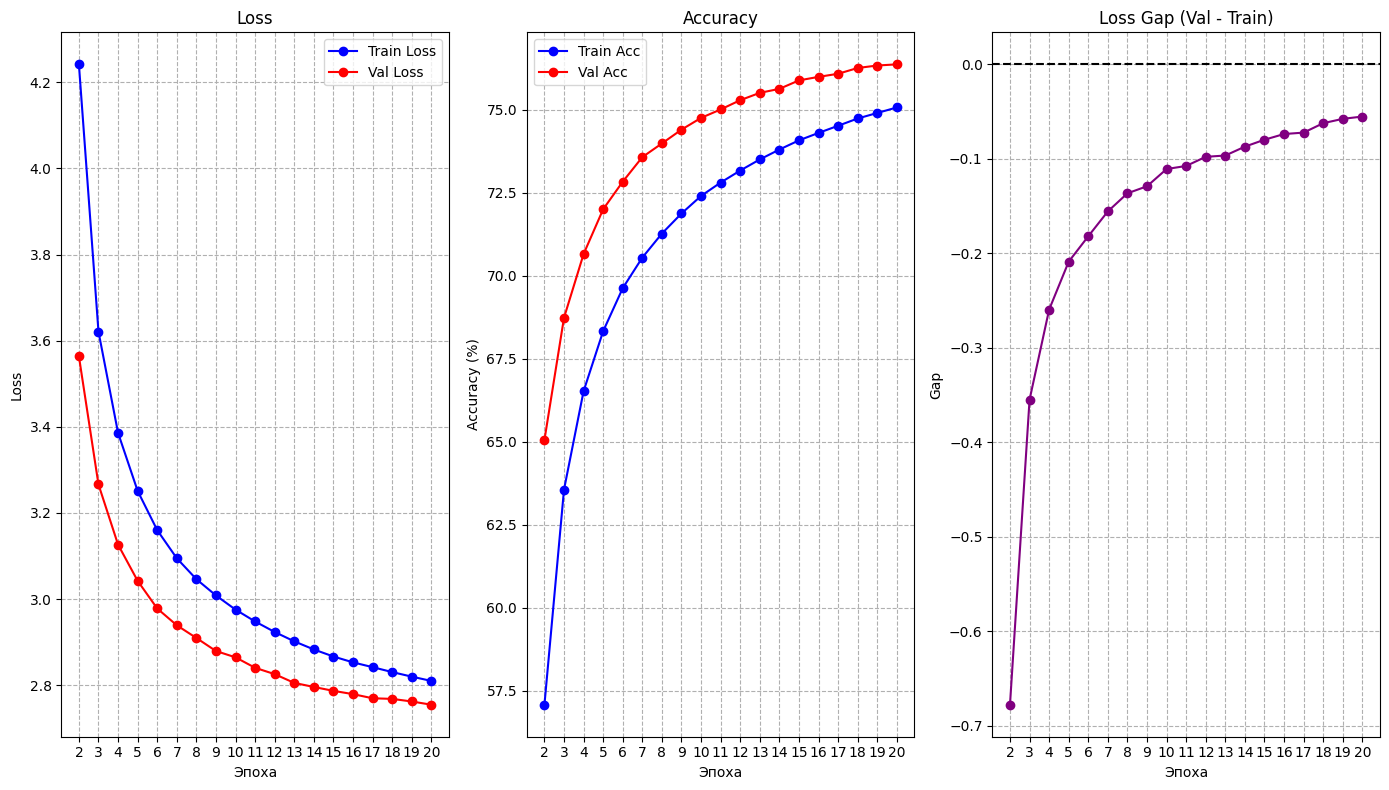

In [21]:
epochs_range = range(2, len(history_train_loss) + 1)

plt.figure(figsize=(14, 8))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, history_train_loss[1:], 'b-o', label='Train Loss')
plt.plot(epochs_range, history_val_loss[1:], 'r-o', label='Val Loss')
plt.title('Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.grid(True, linestyle='--')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_range, history_train_acc[1:], 'b-o', label='Train Acc')
plt.plot(epochs_range, history_val_acc[1:], 'r-o', label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs_range)
plt.grid(True, linestyle='--')
plt.legend()

loss_gap = [val - train for train, val in zip(history_train_loss[1:], history_val_loss[1:])]
plt.subplot(1, 3, 3)
plt.plot(epochs_range, loss_gap, 'purple', marker='o')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Loss Gap (Val - Train)')
plt.xlabel('Эпоха')
plt.ylabel('Gap')
plt.xticks(epochs_range)
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [22]:
checkpoint = torch.load("best_seq2seq_model_transformer.pt", map_location=device, weights_only=True)
transformer_model.load_state_dict(checkpoint["model_state"])

print("Лучшая модель успешно загружена")
print(f"Лучшая эпоха: {checkpoint['epoch']}")
print(f"Лучший Validation Loss: {checkpoint['val_loss']:.4f}")
print(f"Validation Token Accuracy: {checkpoint['val_accuracy']:.2f}%")
print("Config:", checkpoint.get("config", "не сохранена"))

Лучшая модель успешно загружена
Лучшая эпоха: 20
Лучший Validation Loss: 2.7546
Validation Token Accuracy: 76.37%
Config: {'src_vocab_size': 28852, 'tgt_vocab_size': 30000, 'sequence_length': 96, 'hidden_dim': 384, 'intermediate_dim': 1024, 'num_heads': 8, 'num_layers': 5, 'dropout': 0.2}


In [23]:
def generate_translation(input_sentence: str, max_len: int = sequence_length) -> str:
    transformer_model.eval()

    with torch.no_grad():
        source_indices = english_tokenizer.encode(
            input_sentence,
            max_length=sequence_length,
            add_special_tokens=True
        )

        source_tensor = torch.tensor([source_indices], dtype=torch.long, device=device)

        target_indices = [russian_tokenizer.sos_id]

        max_generation_length = min(max_len, sequence_length - 1)

        for _ in range(max_generation_length):
            target_tensor = torch.tensor([target_indices], dtype=torch.long, device=device)

            outputs = transformer_model(source_tensor, target_tensor)

            next_token_logits = outputs[0, -1, :]
            next_token_logits[russian_tokenizer.pad_id] = -float("inf")
            next_token_logits[russian_tokenizer.sos_id] = -float("inf")
            
            next_token_id = torch.argmax(next_token_logits).item()

            target_indices.append(next_token_id)

            if next_token_id == russian_tokenizer.eos_id:
                break

        translation = russian_tokenizer.decode(target_indices)
        return translation

In [26]:
transformer_model.eval()


def bleu_tokenize(text):
    text = re.sub(r"\s+", " ", text.strip())
    return split_text(text)


def evaluate_bleu(pairs, max_samples=None):
    transformer_model.eval()

    hypotheses = []
    references = []

    for i, (eng, rus) in enumerate(tqdm(pairs, desc="Расчет BLEU")):
        if max_samples is not None and i >= max_samples:
            break

        pred = generate_translation(eng).strip()

        hypotheses.append(bleu_tokenize(pred))
        references.append([bleu_tokenize(rus)])

    smoothing = SmoothingFunction().method1

    bleu = corpus_bleu(
        references,
        hypotheses,
        smoothing_function=smoothing
    )

    print(f"BLEU Score ({len(hypotheses)} примеров): {bleu:.4f}")

    return bleu

In [27]:
bleu_result = evaluate_bleu(test_pairs)

Расчет BLEU: 100%|███████████████████████████████████████████████████████████████| 40210/40210 [58:11<00:00, 11.52it/s]


BLEU Score (40210 примеров): 0.4545


In [29]:
test_sentences = [
    "Hello, how are you?",
    "Good morning!",
    "What is your name?",
    
    "She will come tomorrow.",
    "We didn't see him yesterday.",
    "I have never been to Russia.",
    
    "Although it was late, he continued working.",
    "The book that you gave me is very interesting.",
    "If I have time, I will help you.",
    
    "Could you please close the door?",
    "Please turn off the lights.",
    "Why are you late?",
    
    "I love programming.",
    "She likes to read books.",
    "They enjoy playing football.",
    
    "The weather is very good today.",
    "It is raining outside.",
    "The sun is shining brightly.",
    
    "Machine learning is interesting.",
    "Artificial intelligence is the future.",
    "I want to learn data science.",
    
    "It's raining cats and dogs.",
    "Break a leg!",
    "That's a piece of cake.",
]

print("Тестирование на своем наборе\n")

for sentence in test_sentences:
    translation = generate_translation(sentence)
    print(f"EN: {sentence}")
    print(f"RU: {translation}")
    print()

Тестирование на своем наборе

EN: Hello, how are you?
RU: Привет, как ты?

EN: Good morning!
RU: разве утро!

EN: What is your name?
RU: Как тебя зовут?

EN: She will come tomorrow.
RU: Она придёт завтра.

EN: We didn't see him yesterday.
RU: Мы его вчера не видели.

EN: I have never been to Russia.
RU: Я никогда не был в курсе.

EN: Although it was late, he continued working.
RU: Несмотря на то, что опоздал, он продолжал работать.

EN: The book that you gave me is very interesting.
RU: Книга, которую ты мне дал, очень интересная.

EN: If I have time, I will help you.
RU: Если у меня будет время, я тебе помогу.

EN: Could you please close the door?
RU: Не могли бы вы закрыть дверь?

EN: Please turn off the lights.
RU: Выключи свет, пожалуйста.

EN: Why are you late?
RU: Почему ты опоздал?

EN: I love programming.
RU: Я люблю путешествовать.

EN: She likes to read books.
RU: Ей нравится читать книги.

EN: They enjoy playing football.
RU: Им нравится играть в футбол.

EN: The weather is 

In [30]:
import pickle

with open("english_bpe_tokenizer.pkl", "wb") as f:
    pickle.dump({
        "vocabulary": english_tokenizer.vocabulary,
        "merges": english_tokenizer.merges
    }, f)

with open("russian_bpe_tokenizer.pkl", "wb") as f:
    pickle.dump({
        "vocabulary": russian_tokenizer.vocabulary,
        "merges": russian_tokenizer.merges
    }, f)

print("Данные BPE-токенизаторов успешно сохранены")

Данные BPE-токенизаторов успешно сохранены
